In [1]:
import sys
import torch
from sit import SiT_models
from diffusers.models import AutoencoderKL
from PIL import Image
import numpy as np

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

device = torch.device("cuda:0")

## Download and load model weights

In [ ]:
# Download models
import os
from torchvision.datasets.utils import download_url

model_urls = {
    "sit_xl_repa": 'https://www.dl.dropboxusercontent.com/scl/fi/cxedbs4da5ugjq5wg3zrg/last.pt?rlkey=8otgrdkno0nd89po3dpwngwcc&st=apcc645o&dl=0',
    "sit_xl": 'https://huggingface.co/nyu-visionx/SiT-collections/resolve/main/SiT-XL-2-256.pt?download=true',
    "sit_s": 'https://huggingface.co/nyu-visionx/SiT-collections/resolve/main/SiT-S-2-256.pt?download=true',
}

def download_model(model_name):
    """
    Downloads a pre-trained SiT model from the web.
    """
    assert model_name in model_urls.keys()
    local_path = f'ckpts/{model_name}'
    if not os.path.isfile(local_path):
        os.makedirs('ckpts', exist_ok=True)
        web_path = model_urls[model_name]
        download_url(web_path, 'ckpts', filename=model_name+'.pt')

# SiT-XL+REPA
download_model("sit_xl_repa")
# SiT-XL
download_model("sit_xl")
# SiT-S
download_model("sit_s")

In [2]:
# SD-1.5 VAE is shared across models
vae = AutoencoderKL.from_pretrained(f"stabilityai/sd-vae-ft-ema").to(device)

## SiT-XL/2+REPA ##
block_kwargs = {"fused_attn": False, "qk_norm": False}
latent_size = 256 // 8
repa_sit_xl = SiT_models['SiT-XL/2'](
    input_size=latent_size,
    num_classes=1000,
    use_cfg=True,
    z_dims=[768],
    encoder_depth=8,
    **block_kwargs,
).to(device)

ckpt_path = 'ckpts/sit_xl_repa.pt'
state_dict = torch.load(ckpt_path, map_location=device)#['ema']
repa_sit_xl.load_state_dict(state_dict)
repa_sit_xl.eval();  # important!

## SiT-XL/2 ##
block_kwargs = {"fused_attn": False, "qk_norm": False}
latent_size = 256 // 8
sit_xl = SiT_models['SiT-XL/2'](
    input_size=latent_size,
    num_classes=1000,
    use_cfg=True,
    z_dims=[768], #[int(z_dim) for z_dim in args.projector_embed_dims.split(',')],
    encoder_depth=8,
    out_channels=8,
    **block_kwargs,
).to(device)

ckpt_path = 'ckpts/sit_xl.pt'
state_dict = torch.load(ckpt_path, map_location=device)
sit_xl.load_state_dict(state_dict, strict=False)
sit_xl.eval();  # important!

## SiT-S/2 ##
sit_s = SiT_models['SiT-S/2'](
    input_size=latent_size,
    num_classes=1000,
    use_cfg=True,
    z_dims=[768], #[int(z_dim) for z_dim in args.projector_embed_dims.split(',')],
    encoder_depth=12,
    out_channels=8,
    decoder_hidden_size=384,
    **block_kwargs,
).to(device)

ckpt_path = 'ckpts/sit_s.pt'
state_dict = torch.load(ckpt_path, map_location=device)
sit_s.load_state_dict(state_dict, strict=False)
sit_s.eval();  # important!


In [3]:
@torch.no_grad()
def pred_repa_sit(model, z, time_input, y, y_null=None, cfg_scale=1.0):
    if cfg_scale > 1.0:
        assert y_null is not None 

    if cfg_scale > 1.0:
        pred_velocity = model(
            torch.cat((z,z), dim=0),
            torch.cat((time_input,time_input), dim=0),
            torch.cat((y,y_null), dim=0))[0]
        pred_velocity_cond, pred_velocity_uncond = pred_velocity[:z.shape[0],...], pred_velocity[z.shape[0]:,...]
        pred_velocity = pred_velocity_uncond + cfg_scale * (pred_velocity_cond - pred_velocity_uncond)
    else:
        pred_velocity = model(z, time_input, y)[0]
    return pred_velocity

@torch.no_grad()
def pred_sit(model, z, time_input, y, y_null=None, cfg_scale=1.0):
    if cfg_scale > 1.0:
        assert y_null is not None 
    time_input_reversed = 1-time_input # SiT has its time reversed

    if cfg_scale > 1.0:
        # SiT predicts both mean and var
        pred_velocity = -model(
            torch.cat((z,z), dim=0),
            torch.cat((time_input_reversed,time_input_reversed), dim=0),
            torch.cat((y,y_null), dim=0))[0][:,:z.shape[1],:,:]
        pred_velocity_cond, pred_velocity_uncond = pred_velocity[:z.shape[0],...], pred_velocity[z.shape[0]:,...]
        pred_velocity = pred_velocity_uncond + cfg_scale * (pred_velocity_cond - pred_velocity_uncond)
    else:
        pred_velocity = -model(z, time_input_reversed, y)[0][:,:z.shape[1],:,:]
    return pred_velocity


## Generate

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

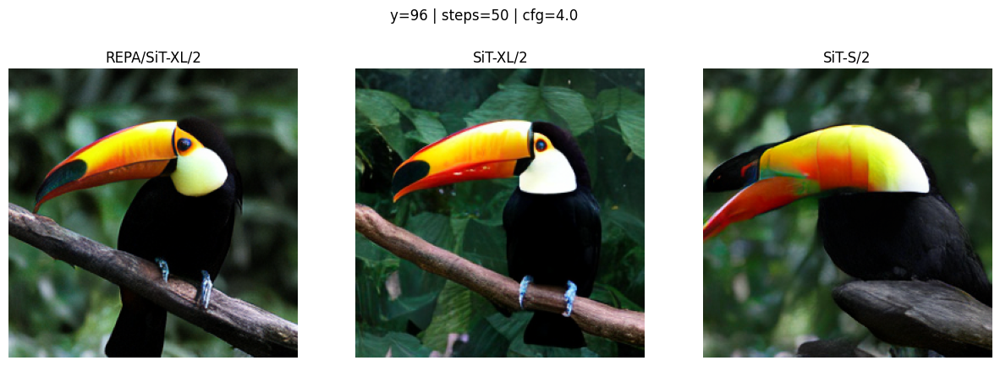

In [5]:
z0 = torch.randn(1, 4, 32, 32, device=device)
y = torch.tensor([96]).long().to(device) # Toucan
# y = torch.randint(0, 1000, (1,)).long().to(device) # Random
y_null = torch.tensor([1000]).long().to(device)

num_steps = 50
cfg_scale = 4.0
t_steps = torch.linspace(1, 0, num_steps+1, dtype=torch.float64)

## REPA/SiT-XL/2 ##
z = z0.clone()
for i, (t_cur, t_next) in tqdm(enumerate(zip(t_steps[:-1], t_steps[1:]))):
    time_input = t_cur * torch.ones((z.shape[0],)).to(device) 
    pred_velocity = pred_repa_sit(repa_sit_xl, z, time_input, y, y_null, cfg_scale)
    z = z + (t_next - t_cur) * pred_velocity
with torch.no_grad():
    img_repa_sit_xl = ((vae.decode(z / 0.18215).sample+1)*0.5).clamp(0,1).permute(0, 2, 3, 1).cpu().numpy()

## SiT-XL/2 ##
z = z0.clone()
for i, (t_cur, t_next) in tqdm(enumerate(zip(t_steps[:-1], t_steps[1:]))):
    time_input = t_cur * torch.ones((z.shape[0],)).to(device) 
    pred_velocity = pred_sit(sit_xl, z, time_input, y, y_null, cfg_scale)
    z = z + (t_next - t_cur) * pred_velocity
with torch.no_grad():
    img_sit_xl = ((vae.decode(z / 0.18215).sample+1)*0.5).clamp(0,1).permute(0, 2, 3, 1).cpu().numpy()

## SiT-S/2 ##
z = z0.clone()
for i, (t_cur, t_next) in tqdm(enumerate(zip(t_steps[:-1], t_steps[1:]))):
    time_input = t_cur * torch.ones((z.shape[0],)).to(device) 
    pred_velocity = pred_sit(sit_s, z, time_input, y, y_null, cfg_scale)
    z = z + (t_next - t_cur) * pred_velocity
with torch.no_grad():
    img_sit_s = ((vae.decode(z / 0.18215).sample+1)*0.5).clamp(0,1).permute(0, 2, 3, 1).cpu().numpy()


fig, ax = plt.subplots(1, 3, figsize=(15,5))
ax[0].imshow(img_repa_sit_xl[0])
ax[0].set_title("REPA/SiT-XL/2")
ax[0].axis('off')

ax[1].imshow(img_sit_xl[0])
ax[1].set_title("SiT-XL/2")
ax[1].axis('off')

ax[2].imshow(img_sit_s[0])
ax[2].set_title("SiT-S/2")
ax[2].axis('off')

plt.suptitle(f"y={y.item()} | steps={num_steps} | cfg={cfg_scale}")
plt.show()


## Compute eigenvectors/eigenvalues

In [6]:
def get_eigenvectors(model, pred_func, z, time_input, y, y_null, cfg_scale, n_eigenvectors, n_iters):
    # Point around which J is approximated
    pred_velocity = pred_func(model, z, time_input, y, y_null, cfg_scale)
    z0_pred = z - (time_input) * pred_velocity

    def jacobian_vector_approx(v, bs=10):
        h = 1
        jv_all = []
        for i in range(0, v.shape[0], bs):
            v_batch = v[i:i+bs,...]
            bb = v_batch.shape[0]

            z_perturbed = z.tile(bb,1,1,1) + h*v_batch
            velocity_perturbed = pred_func(model, z_perturbed, time_input.tile(bb), y.tile(bb), y_null.tile(bb), cfg_scale)
                
            z0_perturbed = z_perturbed - (time_input) * velocity_perturbed
            jv = (z0_perturbed - z0_pred.tile(bb,1,1,1)) / h
            jv_all.append(jv)
        jv_all = torch.cat(jv_all, dim=0)
        return jv_all

    # Run simultaneous iteration
    qf = torch.randn((4*32*32, n_eigenvectors), device=device)
    for _ in range(n_iters):
        JF = jacobian_vector_approx(qf.T.view(n_eigenvectors,4,32,32))
        JF = JF.reshape(n_eigenvectors,4*32*32).T
        qf, rf = torch.linalg.qr(JF)

    eigenvectors = [
        qf[:,b].view(1,4,32,32) for b in range(qf.shape[1])
    ]
    eigenvalues = [
        jacobian_vector_approx(qf[:,b].view(1,4,32,32)).view(-1).norm().item() for b in range(qf.shape[1])
    ]
    return eigenvectors, eigenvalues, z0_pred


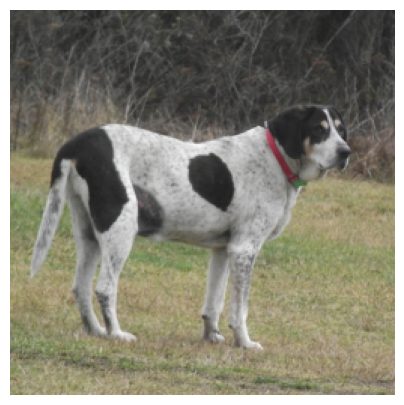

In [8]:
# Load image
image = np.asarray(Image.open("dog.png").convert("RGB"))/255.
image = torch.from_numpy(image).permute([2,0,1]).unsqueeze(0)
image = 2*(image-0.5)

# Encode with VAE
with torch.no_grad():
    latent = vae.encode(image.float().to(device))['latent_dist'].mean * 0.18215
    reconstructed_image = vae.decode(latent / 0.18215).sample

fig, ax = plt.subplots(1, 1, figsize=(5,5))
ax.imshow((0.5*(image+1)).clip(0,1)[0].cpu().numpy().transpose([1,2,0]))
# ax.imshow((0.5*(reconstructed_image+1)).clip(0,1)[0].cpu().numpy().transpose([1,2,0]))
ax.axis('off')
plt.show()

In [9]:
# Create noisy latent
# Timesteps are inverted in pretrained models
# Noise 1 --> 0 Data
tt = 0.6
cfg_scale = 1.0

# Add noise to image
t_cur = tt
z0 = (1-t_cur)*latent + (t_cur)*torch.randn_like(latent)
y = torch.tensor([164]).long().to(device) # 164: bluetick
y_null = torch.tensor([1000]).long().to(device)

In [10]:
# Compute eigenvectors
z = z0.clone()
time_input = t_cur * torch.ones((z.shape[0],)).to(device) 

eigenvectors_repa_sit_xl, eigenvalues_repa_sit_xl, z0_pred_repa_sit_xl = get_eigenvectors(
    repa_sit_xl, pred_repa_sit, z, time_input, y, y_null, cfg_scale,
    n_eigenvectors=10, n_iters=10
)

eigenvectors_sit_xl, eigenvalues_sit_xl, z0_pred_sit_xl = get_eigenvectors(
    sit_xl, pred_sit, z, time_input, y, y_null, cfg_scale,
    n_eigenvectors=10, n_iters=10
)

eigenvectors_sit_s, eigenvalues_sit_s, z0_pred_sit_s = get_eigenvectors(
    sit_s, pred_sit, z, time_input, y, y_null, cfg_scale,
    n_eigenvectors=10, n_iters=10
)

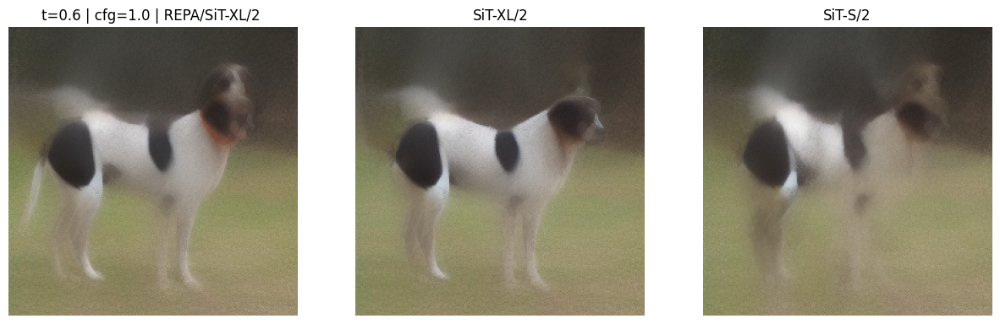

In [11]:
with torch.no_grad():
    pred_img_repa_sit_xl = ((vae.decode(z0_pred_repa_sit_xl / 0.18215).sample + 1)*0.5).clamp(0,1)
    pred_img_sit_xl = ((vae.decode(z0_pred_sit_xl / 0.18215).sample + 1)*0.5).clamp(0,1)
    pred_img_sit_s = ((vae.decode(z0_pred_sit_s / 0.18215).sample + 1)*0.5).clamp(0,1)
    decoder_bias = ((vae.decode(0*z0_pred_sit_s / 0.18215).sample + 1)*0.5).clamp(0,1)

fig, ax = plt.subplots(1, 3, figsize=(15,5))
ax[0].imshow(pred_img_repa_sit_xl[0].clamp(0,1).permute([1,2,0]).cpu().float().numpy())
ax[0].set_title(f"t={t_cur} | cfg={cfg_scale} | REPA/SiT-XL/2 ")
ax[0].axis('off')
ax[1].imshow(pred_img_sit_xl[0].clamp(0,1).permute([1,2,0]).cpu().float().numpy())
ax[1].set_title(f"SiT-XL/2")
ax[1].axis('off')
ax[2].imshow(pred_img_sit_s[0].clamp(0,1).permute([1,2,0]).cpu().float().numpy())
ax[2].set_title(f"SiT-S/2")
ax[2].axis('off')
plt.show()

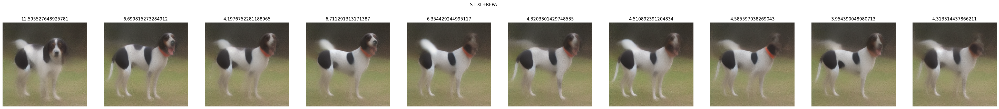

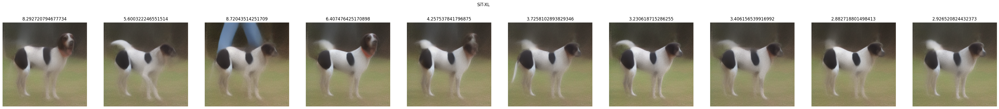

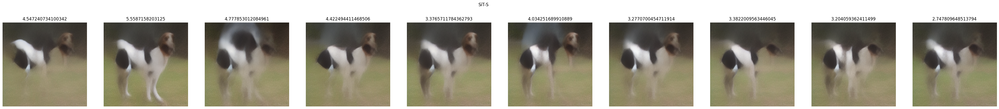

In [17]:
all_model_names = ["SiT-XL+REPA", "SiT-XL", "SiT-S"]
all_models = [repa_sit_xl, sit_xl, sit_s]
all_eigvecs = [eigenvectors_repa_sit_xl, eigenvectors_sit_xl, eigenvectors_sit_s]
all_eigvals = [eigenvalues_repa_sit_xl, eigenvalues_sit_xl, eigenvalues_sit_s]

delta = 2.0

for model_name, model, eigvecs, eigvals in zip(all_model_names, all_models, all_eigvecs, all_eigvals):
    n_eigenvectors = len(eigvecs)
    fig, ax = plt.subplots(1, n_eigenvectors, figsize=(5*n_eigenvectors,5))
    for j in range(n_eigenvectors):
        with torch.no_grad():
            z_new = z + delta*eigvecs[j]
            if "REPA" in model_name:
                pred_velocity_new = pred_repa_sit(model, z_new, time_input, y, y_null, cfg_scale)
            else:
                pred_velocity_new = pred_sit(model, z_new, time_input, y, y_null, cfg_scale)
            z0_pred_new = z_new - (t_cur) * pred_velocity_new
            pred_img_new = 0.5*(vae.decode(z0_pred_new / 0.18215).sample+1)

        ax[j].imshow(pred_img_new[0].clamp(0,1).permute([1,2,0]).cpu().float().numpy())
        ax[j].set_title(f"{eigvals[j]}")
        ax[j].axis("off")
    plt.suptitle(f"{model_name}")
    plt.show()

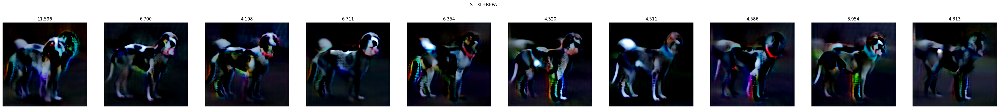

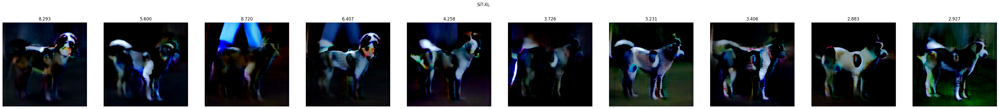

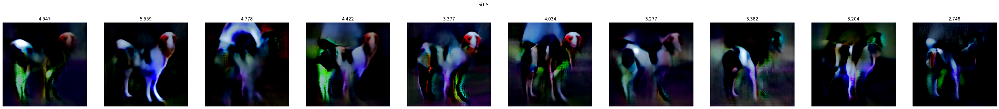

In [ ]:
all_model_names = ["SiT-XL+REPA", "SiT-XL", "SiT-S"]
all_models = [repa_sit_xl, sit_xl, sit_s]
all_eigvecs = [eigenvectors_repa_sit_xl, eigenvectors_sit_xl, eigenvectors_sit_s]
all_eigvals = [eigenvalues_repa_sit_xl, eigenvalues_sit_xl, eigenvalues_sit_s]

scaling = 100

for model_name, model, eigvecs, eigvals in zip(all_model_names, all_models, all_eigvecs, all_eigvals):
    n_eigenvectors = len(eigvecs)
    fig, ax = plt.subplots(1, n_eigenvectors, figsize=(5*n_eigenvectors,5))
    for j in range(n_eigenvectors):
        with torch.no_grad():
            pred_img = 0.5*(vae.decode(scaling*eigvecs[j] / 0.18215).sample+1) - decoder_bias
        ax[j].imshow(pred_img[0].clamp(0,1).permute([1,2,0]).cpu().float().numpy())
        ax[j].set_title(f"{eigvals[j]:.3f}")
        ax[j].axis("off")
    plt.suptitle(f"{model_name}")
    plt.show()